In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph,MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage ,AIMessage , RemoveMessage
from typing import Literal

In [3]:
class State(MessagesState):
    summery : str

In [4]:
chat = ChatOpenAI(
    model = 'gpt-4o',
    seed = 365,
    temperature = 0.9,
    max_tokens=500
)

In [5]:
def ask_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_question:")
    question = "What is your question?"
    print(question)

    return State(
        messages = [AIMessage(question), HumanMessage(input())]
    )

In [6]:
def chat_bot(state : State) -> State:
    print(f'\n---------------chat_bot Started')
    for i in state['messages']:
        i.pretty_print()

    # adding logic to get summary to latest question instead of all previous inputs

    system_message = f'''
        Here's a quick summary of what's been discussed so far:
        {state.get('summery','')}
        Keep this in mind as you answer the next question.
    '''
    response = chat.invoke(
        [SystemMessage(system_message)] + state["messages"]
    )

    response.pretty_print()

    return State(
        messages = [response]
    )

In [7]:
def remove_message(state: State) -> State:
    print(f'\n---------------remove_message Started')
    remove_messages = [
        RemoveMessage(id=i.id)
        for i in state['messages'][:]
    ]
    return State(messages=remove_messages)

In [8]:
def ask_another_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_another_question:")
    question = "Would you like to ask one more question (yes/no)?"
    print(question)

    return State(
        messages = [AIMessage(content=question),HumanMessage(content=input())]
    )

In [9]:
def routing_function(state: State) -> Literal["summarize_and_delete_messages", END]:

    if state["messages"][-1].content == "yes":
        return "summarize_and_delete_messages"
    return END

In [10]:
def summarize_and_delete_messages(state: State) -> State:
    print(f"\n-------> ENTERING trim_messages:")
    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f'''
        Update the ongoing summary by incorporating the new lines of conversation below.
        Build upon the previous summary rather than repeating it so that the result
        reflects the most recent context and developments.

        Previous Summary:
        {state.get("summary", "")}

        New Conversation:
        {new_conversation}
        '''
    summary = chat.invoke([HumanMessage(summary_instructions)])
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]

    return State(
        messages = remove_messages,
        summary = summary.content
    )


##Build Graph

In [11]:
graph = StateGraph(State)

In [12]:
graph.add_node("ask_question", ask_question)
graph.add_node("chat_bot",chat_bot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

In [13]:
graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chat_bot")
graph.add_edge("chat_bot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question",
                            path = routing_function)
graph.add_edge("summarize_and_delete_messages", "ask_question")

In [14]:
graph_compiled = graph.compile()

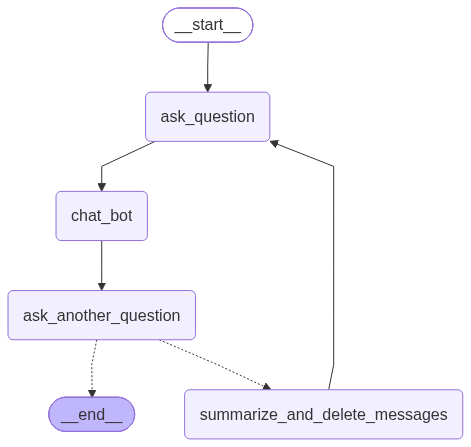

In [15]:
graph_compiled

In [16]:
graph_compiled.invoke(
    MessagesState(messages=[])
)


-------> ENTERING ask_question:
What is your question?


KeyboardInterrupt: Interrupted by user